In [1]:
import sys
import os
# Get the parent directory
parent_folder = os.path.dirname(os.getcwd())
# add the parent directory to the Python path so that the scripts can be imported
sys.path.append(parent_folder)

In [2]:
from modules.preprocessing import data_preprocessor
from modules.utils import split_households, df_common_xylabel_plot, read_column_list_from_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use('science')

In [3]:
fname = '../data/ausgrid/ausgrid_merged_unprocessed.csv'
df = pd.read_csv(fname)

## Data Cleaning
Remove the anomalous households: [103, 148, 230, 269, 281]

In [4]:
df.shape

(52608, 258)

In [5]:
# remove columns that start with '103', '148', '230', '269', '281'
df = df.loc[:, ~df.columns.str.startswith(
    ('103', '148', '230', '269', '281'))]
df.shape

(52608, 258)

# Split the households

In [6]:
time_columns = read_column_list_from_config('../config/time_columns.txt')
weather_columns = read_column_list_from_config(
    '../config/weather_columns_preprocess.txt')
feature_columns = read_column_list_from_config(
    '../config/feature_columns_preprocess.txt')
n_1 = 39
n_2 = 38
seed = 42
df = df[(df['datetime'] >= '2012-07-01')
        & (df['datetime'] <= '2013-07-01')]
# reset the index
df = df.reset_index(drop=True)

In [7]:
df_1, df_2 = split_households(df, n_1=n_1, n_2=n_2, seed=seed,
                              date_columns=time_columns, weather_columns=weather_columns)

In [8]:
df_1.columns

Index(['53_pv', '12_pv', '129_pv', '118_pv', '105_pv', '60_pv', '48_pv',
       '275_pv', '44_pv', '213_pv',
       ...
       'ghi_loc3', 'azimuth', 'zenith', 'cloud_opacity', 'datetime', 'HoD',
       'dow', 'doy', 'month', 'year'],
      dtype='object', length=132)

In [9]:
df_2.columns

Index(['56_pv', '194_pv', '62_pv', '192_pv', '251_pv', '131_pv', '32_pv',
       '193_pv', '116_pv', '140_pv',
       ...
       'ghi_loc3', 'azimuth', 'zenith', 'cloud_opacity', 'datetime', 'HoD',
       'dow', 'doy', 'month', 'year'],
      dtype='object', length=129)

In [10]:
# Preprocess the data
preprocessor_0 = data_preprocessor(df)
preprocessor_1 = data_preprocessor(df_1)
preprocessor_2 = data_preprocessor(df_2)

# Estimate PV capacity from PV profiles

In [11]:
preprocessor_0.estimate_pv_capacity_from_pv_profiles_avg_high_values()
preprocessor_1.estimate_pv_capacity_from_pv_profiles_avg_high_values()
preprocessor_2.estimate_pv_capacity_from_pv_profiles_avg_high_values()

In [12]:
preprocessor_0.pv_capacity_from_pv_profiles.to_csv(
    '../data/ausgrid/ausgrid_pv_capacity_from_pv_profiles.csv', index=True)

# Normalize the PV generation


In [13]:
preprocessor_0.normalize_pv()
preprocessor_1.normalize_pv()
preprocessor_2.normalize_pv()

,56_pv,194_pv,62_pv,192_pv,251_pv,131_pv,32_pv,193_pv,116_pv,140_pv,...,ghi_loc3,azimuth,zenith,cloud_opacity,datetime,HoD,dow,doy,month,year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,164,169,12.0,2012-07-01 00:00:00,0,6,183,7,2012
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,-161,169,0.0,2012-07-01 00:30:00,0,6,183,7,2012
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,-134,165,0.0,2012-07-01 01:00:00,1,6,183,7,2012
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,-118,160,0.0,2012-07-01 01:30:00,1,6,183,7,2012
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,-108,154,0.0,2012-07-01 02:00:00,2,6,183,7,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,96,143,0.0,2013-06-30 21:30:00,21,6,181,6,2013
17516,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,101,149,0.0,2013-06-30 22:00:00,22,6,181,6,2013
17517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,108,155,0.0,2013-06-30 22:30:00,22,6,181,6,2013
17518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,119,161,0.0,2013-06-30 23:00:00,23,6,181,6,2013


# Add total pv, con and net

In [14]:
preprocessor_1.add_total_pv_gen()
preprocessor_1.add_total_pv_gen_normalized(
    capacity=preprocessor_1.pv_capacity_from_pv_profiles)
preprocessor_2.add_total_pv_gen()
preprocessor_2.add_total_pv_gen_normalized(
    capacity=preprocessor_2.pv_capacity_from_pv_profiles)
preprocessor_1.add_total_net()
preprocessor_2.add_total_net()
preprocessor_1.add_total_con()
preprocessor_2.add_total_con()

In [15]:
preprocessor_1.normalize_feature(
    feature_list=['total_net', 'total_pv_gen'])
preprocessor_2.normalize_feature(
    feature_list=['total_net', 'total_pv_gen'])

## Compare the distribution between calibration and test

# Feature Engineering



In [16]:
preprocessor_1.add_cos_sin_HoD()
preprocessor_2.add_cos_sin_HoD()

# Normalize the features

In [17]:
feature_columns_to_normalize = [
    col for col in feature_columns if col != 'total_net_norm']

In [18]:
preprocessor_1.normalize_feature(feature_list=feature_columns_to_normalize)
preprocessor_2.normalize_feature(feature_list=feature_columns_to_normalize)

/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/home/jhe/prjs/envs_py/prob-trans/lib/python3.12/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


### Check the distribution

In [19]:
col_total_pv_gen_norm = ['total_pv_gen_normalized']
col_total_net_norm = ['total_net_norm']
col_ghi = ['ghi']

#### Net load

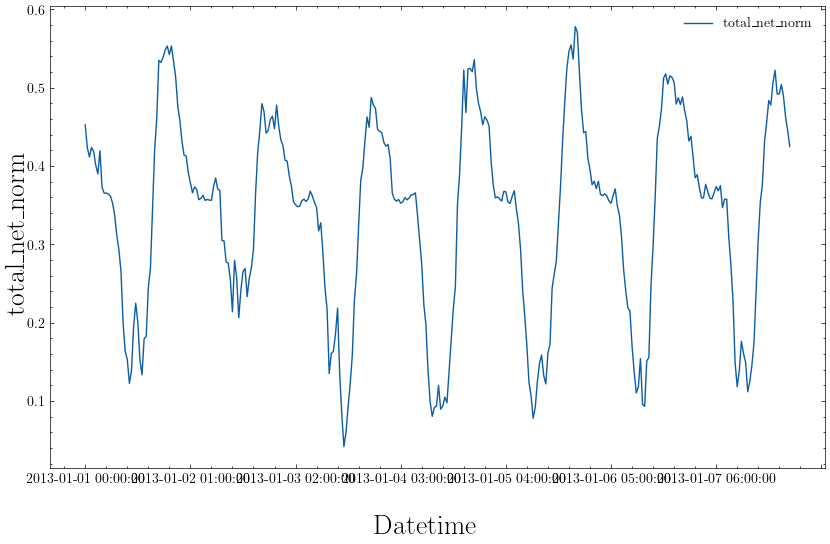

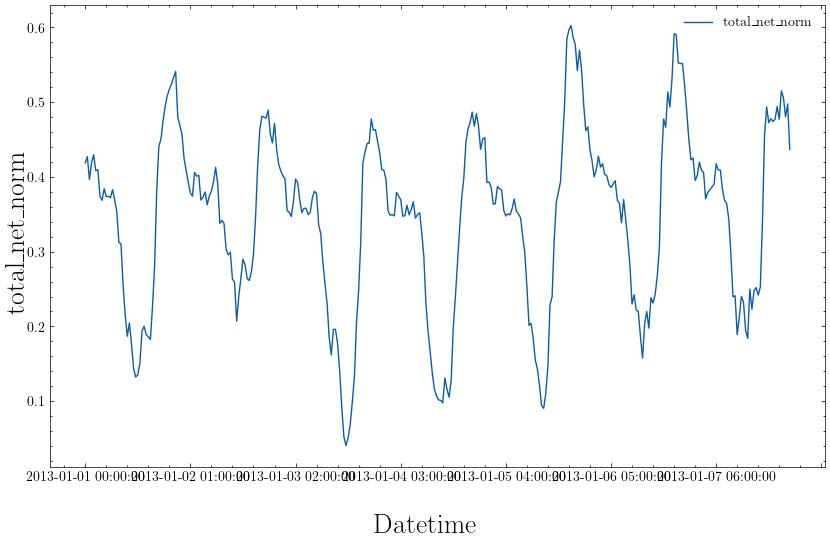

In [20]:
df_common_xylabel_plot(preprocessor_1.data_pv_normalized, col_total_net_norm, doy_start=0, doy_end=7, year=[
                       2013], xlabel='Datetime', ylabel="total_net_norm", layout=(1, 1), subplots=True, figsize=(10, 6))
df_common_xylabel_plot(preprocessor_2.data_pv_normalized, col_total_net_norm, doy_start=0, doy_end=7, year=[
                       2013], xlabel='Datetime', ylabel="total_net_norm", layout=(1, 1), subplots=True, figsize=(10, 6))

<Axes: xlabel='datetime'>

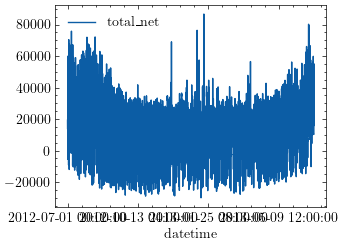

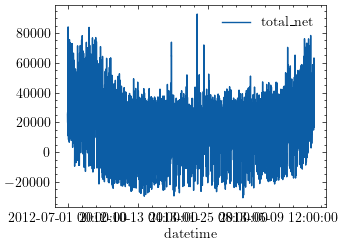

In [21]:
# plot 'total_pv_gen_normalized'  against datetime
preprocessor_1.data_pv_normalized.plot(
    x='datetime', y='total_net')
preprocessor_2.data_pv_normalized.plot(
    x='datetime', y='total_net')

<Axes: xlabel='datetime'>

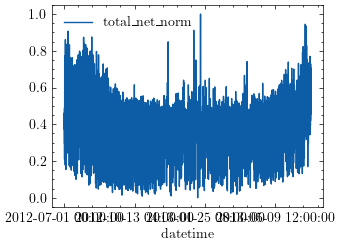

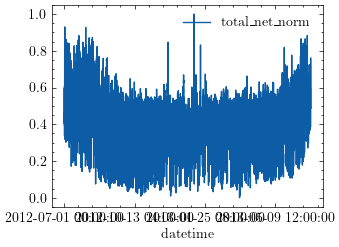

In [22]:
# plot 'total_pv_gen_normalized'  against datetime
preprocessor_1.data_pv_normalized.plot(
    x='datetime', y='total_net_norm')
preprocessor_2.data_pv_normalized.plot(
    x='datetime', y='total_net_norm')

Text(0.5, 0, 'total_net_norm')

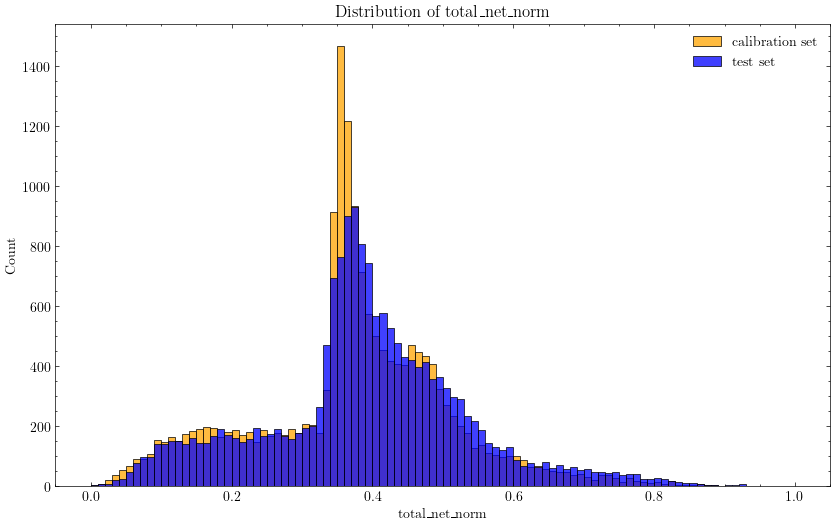

In [23]:
# plot the distribution of total_pv_gen_normalized for both preprocessor_1.data_pv_normalized and preprocessor_2.data_pv_normalized
# with different colors
# larger figure size
plt.figure(figsize=(10, 6))
sns.histplot(
    preprocessor_1.data_pv_normalized['total_net_norm'], bins=100, color='orange')
sns.histplot(
    preprocessor_2.data_pv_normalized['total_net_norm'], bins=100, color='blue')
# add legend
plt.legend(['calibration set', 'test set'])
# add title
plt.title('Distribution of total_net_norm')
# add x label
plt.xlabel('total_net_norm')

In [24]:
preprocessor_1.data_pv_normalized.columns.tolist()

['53_pv',
 '12_pv',
 '129_pv',
 '118_pv',
 '105_pv',
 '60_pv',
 '48_pv',
 '275_pv',
 '44_pv',
 '213_pv',
 '16_pv',
 '291_pv',
 '268_pv',
 '99_pv',
 '298_pv',
 '120_pv',
 '139_pv',
 '6_pv',
 '288_pv',
 '45_pv',
 '172_pv',
 '156_pv',
 '164_pv',
 '128_pv',
 '98_pv',
 '242_pv',
 '279_pv',
 '135_pv',
 '278_pv',
 '4_pv',
 '43_pv',
 '264_pv',
 '244_pv',
 '78_pv',
 '182_pv',
 '40_pv',
 '277_pv',
 '162_pv',
 '31_pv',
 '53_con',
 '12_con',
 '129_con',
 '118_con',
 '105_con',
 '60_con',
 '48_con',
 '275_con',
 '44_con',
 '213_con',
 '16_con',
 '291_con',
 '268_con',
 '99_con',
 '298_con',
 '120_con',
 '139_con',
 '6_con',
 '288_con',
 '45_con',
 '172_con',
 '156_con',
 '164_con',
 '128_con',
 '98_con',
 '242_con',
 '279_con',
 '135_con',
 '278_con',
 '4_con',
 '43_con',
 '264_con',
 '244_con',
 '78_con',
 '182_con',
 '40_con',
 '277_con',
 '162_con',
 '31_con',
 '53_net',
 '12_net',
 '129_net',
 '118_net',
 '105_net',
 '60_net',
 '48_net',
 '275_net',
 '44_net',
 '213_net',
 '16_net',
 '291_net',

In [25]:
# get all the columns that start with a number and end with _pv
pv_cols = [col for col in preprocessor_1.data_pv_normalized.columns
           if col[0].isdigit() and col.endswith('_pv')]
pv_cols

['53_pv',
 '12_pv',
 '129_pv',
 '118_pv',
 '105_pv',
 '60_pv',
 '48_pv',
 '275_pv',
 '44_pv',
 '213_pv',
 '16_pv',
 '291_pv',
 '268_pv',
 '99_pv',
 '298_pv',
 '120_pv',
 '139_pv',
 '6_pv',
 '288_pv',
 '45_pv',
 '172_pv',
 '156_pv',
 '164_pv',
 '128_pv',
 '98_pv',
 '242_pv',
 '279_pv',
 '135_pv',
 '278_pv',
 '4_pv',
 '43_pv',
 '264_pv',
 '244_pv',
 '78_pv',
 '182_pv',
 '40_pv',
 '277_pv',
 '162_pv',
 '31_pv']

#### PV generation

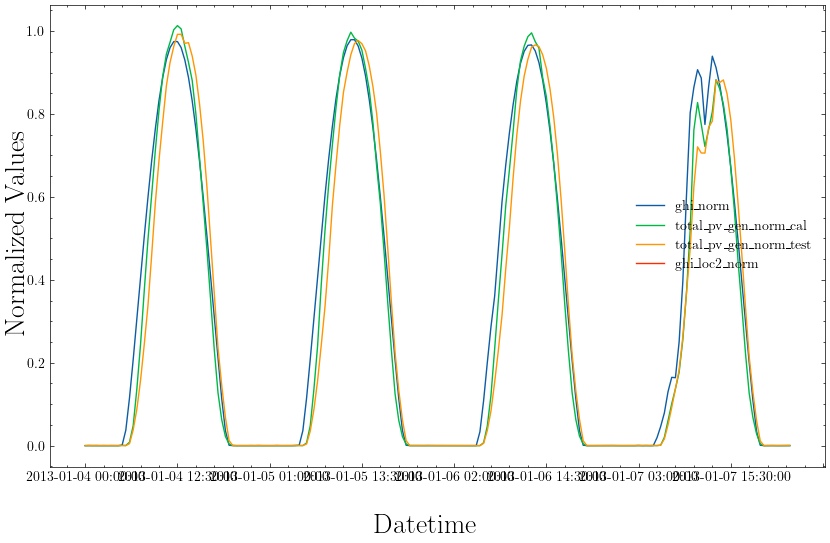

In [26]:
new_df = preprocessor_1.data_pv_normalized.copy()
new_df['total_pv_gen_norm_cal'] = preprocessor_1.data_pv_normalized['total_pv_gen_normalized']
new_df['total_pv_gen_norm_test'] = preprocessor_2.data_pv_normalized['total_pv_gen_normalized']
# cols_to_plot = ['total_pv_gen_norm_cal',
#                 'total_pv_gen_norm_test', 'ghi_norm', 'ghi_loc2_norm', 'ghi_loc3_norm']
cols_to_plot = ['ghi_norm'] + \
    ['total_pv_gen_norm_cal'] + ['total_pv_gen_norm_test'] + ['ghi_loc2_norm']
# cols_to_plot = pv_cols[7:8] + ['ghi_norm', 'ghi_loc2_norm', 'ghi_loc3_norm']
df_common_xylabel_plot(new_df, cols_to_plot, doy_start=4, doy_end=7, year=[
                       2013], xlabel='Datetime', ylabel="Normalized Values", layout=(1, 1), subplots=False, figsize=(10, 6))

<Axes: xlabel='datetime'>

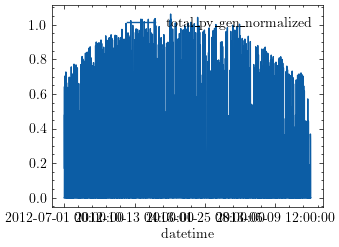

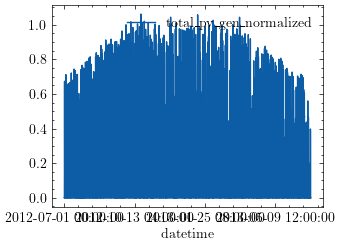

In [27]:
# plot 'total_pv_gen_normalized'  against datetime
preprocessor_1.data_pv_normalized.plot(
    x='datetime', y='total_pv_gen_normalized')
preprocessor_2.data_pv_normalized.plot(
    x='datetime', y='total_pv_gen_normalized')

In [28]:
preprocessor_1.data_pv_normalized[['total_pv_gen_normalized']].describe()

,total_pv_gen_normalized
count,17520.000000
mean,0.189777
std,0.285852
min,0.000000
25%,0.000000
50%,0.000534
75%,0.325006
max,1.060724


In [29]:
preprocessor_2.data_pv_normalized[['total_pv_gen_normalized']].describe()

,total_pv_gen_normalized
count,17520.000000
mean,0.190777
std,0.285210
min,0.000000
25%,0.000000
50%,0.000535
75%,0.331467
max,1.061960


<Axes: xlabel='datetime'>

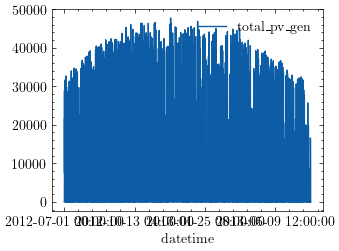

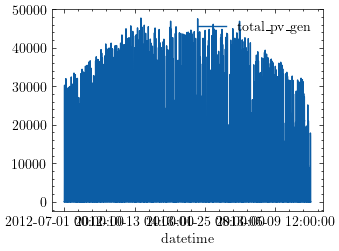

In [30]:
# plot 'total_pv_gen_normalized'  against datetime
preprocessor_1.data_pv_normalized.plot(
    x='datetime', y='total_pv_gen')
preprocessor_2.data_pv_normalized.plot(
    x='datetime', y='total_pv_gen')

In [31]:
preprocessor_1.data_pv_normalized[['total_pv_gen_normalized']].describe()

,total_pv_gen_normalized
count,17520.000000
mean,0.189777
std,0.285852
min,0.000000
25%,0.000000
50%,0.000534
75%,0.325006
max,1.060724


In [32]:
preprocessor_2.data_pv_normalized[['total_pv_gen_normalized']].describe()

,total_pv_gen_normalized
count,17520.000000
mean,0.190777
std,0.285210
min,0.000000
25%,0.000000
50%,0.000535
75%,0.331467
max,1.061960


<Axes: xlabel='datetime'>

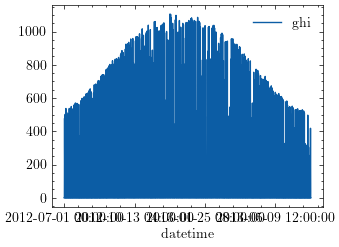

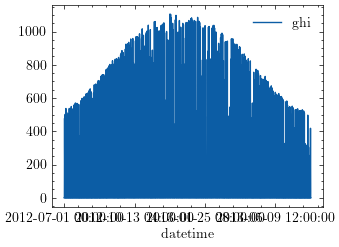

In [33]:
# plot 'total_pv_gen_normalized'  against datetime
preprocessor_1.data_pv_normalized.plot(
    x='datetime', y='ghi')
preprocessor_2.data_pv_normalized.plot(
    x='datetime', y='ghi')

(0.0, 1000.0)

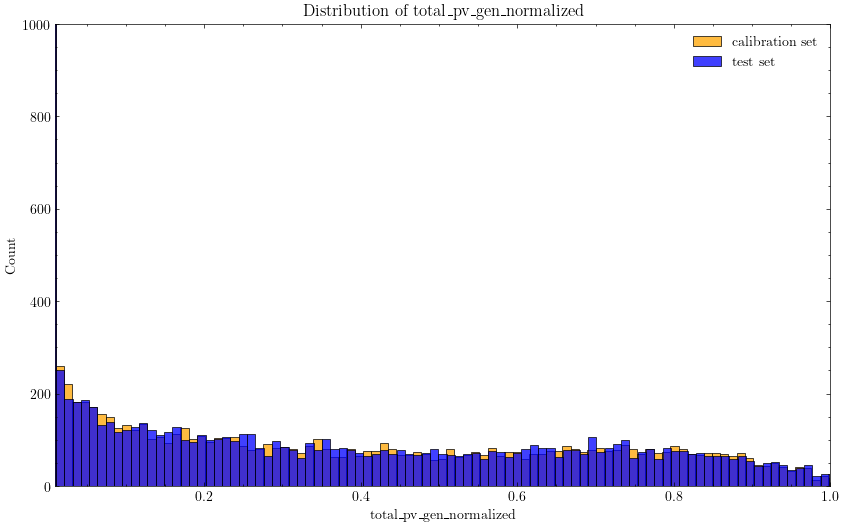

In [34]:
# plot the distribution of total_pv_gen_normalized for both preprocessor_1.data_pv_normalized and preprocessor_2.data_pv_normalized
# with different colors
# larger figure size
plt.figure(figsize=(10, 6))
sns.histplot(
    preprocessor_1.data_pv_normalized['total_pv_gen_normalized'], bins=100, color='orange')
sns.histplot(
    preprocessor_2.data_pv_normalized['total_pv_gen_normalized'], bins=100, color='blue')
# add legend
plt.legend(['calibration set', 'test set'])
# add title
plt.title('Distribution of total_pv_gen_normalized')
# add x label
plt.xlabel('total_pv_gen_normalized')
plt.xlim(0.01, 1)
plt.ylim(0, 1000)

#### Consumption

<Axes: xlabel='datetime'>

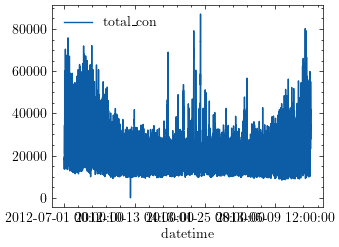

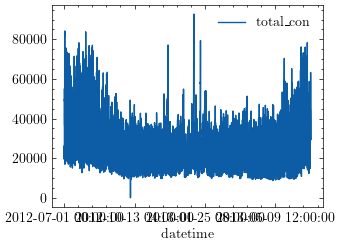

In [35]:
# plot 'total_pv_gen_normalized'  against datetime
preprocessor_1.data_pv_normalized.plot(
    x='datetime', y='total_con')
preprocessor_2.data_pv_normalized.plot(
    x='datetime', y='total_con')

# Save the preprocessed data


In [36]:
preprocessor_0.data_pv_normalized.to_csv(
    '../data/ausgrid/ausgrid_merged_preprocessed.csv', index=False)
preprocessor_1.data_pv_normalized.to_csv(
    '../data/ausgrid/ausgrid_merged_preprocessed_part1.csv', index=False)
preprocessor_2.data_pv_normalized.to_csv(
    '../data/ausgrid/ausgrid_merged_preprocessed_part2.csv', index=False)